# Library import

In [1]:
# Core PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F

# Torchvision (datasets & transforms)
from torchvision import datasets, transforms

# Data utilities
from torch.utils.data import DataLoader, Subset, random_split, WeightedRandomSampler

# Optimization
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical
import numpy as np
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


# Data Loading

In [2]:
# Path
data_dir = "/kaggle/input/datasets/saikottech/plant-leaf-diseases/Dataset/Plant_leaf_diseases_dataset_without_augmentation"

In [3]:
# Load full dataset
full_dataset = datasets.ImageFolder(root=data_dir)

# Preprocessing & Augmentation

In [4]:
# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
     transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
     transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

In [6]:
# Dataset size
dataset_size = len(full_dataset)

# Split sizes
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

# Split full dataset
train_data, val_data, test_data = random_split(
    full_dataset, [train_size, val_size, test_size]
)

# Apply transforms
train_data.dataset.transform = train_transform
val_data.dataset.transform   = test_transform
test_data.dataset.transform  = test_transform

# Compute class counts
labels = np.array([full_dataset.targets[i] for i in train_data.indices])
class_counts = np.bincount(labels)

# Compute weights and create WeightedRandomSampler(better than random shuffle)
weights = 1. / torch.tensor(class_counts, dtype=torch.float)
samples_weights = weights[labels]
sampler = WeightedRandomSampler(samples_weights, num_samples=len(samples_weights), replacement=True)

**Explanation**

This code splits the dataset, applies transforms, and handles class imbalance:

Dataset split:
* 70% train, 15% validation, 15% test
Apply transforms:
* Training and test/validation transformations applied separately
Class balancing:
* Computes class counts from training subset
* Creates WeightedRandomSampler which ensures minority classes are sampled more often

In [12]:
# Hyperparameters & Dataloaders
batch_size = 32
learning_rate = 0.001
minimum_learning_rate=1e-4
epochs = 30

train_loader = DataLoader(
    train_data, batch_size=batch_size, sampler=sampler, num_workers=2, 
    pin_memory = torch.cuda.is_available(), 
    persistent_workers=True, prefetch_factor=2, drop_last=True
)

val_loader = DataLoader(
    val_data, batch_size=batch_size, shuffle=False, num_workers=2, 
    pin_memory = torch.cuda.is_available(), 
    persistent_workers=True, prefetch_factor=2, drop_last=False
)

test_loader = DataLoader(
    test_data, batch_size=batch_size, shuffle=False, num_workers=2, 
    pin_memory = torch.cuda.is_available(),
    persistent_workers=True, prefetch_factor=2, drop_last=False
)

**Explanation**

This code sets batch size, learning rate, and creates train, validation, and test DataLoaders.

* Train loader uses a sampler to handle class imbalance.
* Val/test loaders don’t shuffle and keep all samples.
* pin_memory and persistent_workers speed up GPU data loading.

In [14]:
# Check
print("Total image:", dataset_size)
print("Train:", len(train_data))
print("Val:", len(val_data))
print("Test:", len(test_data))

Total subset: 55448
Train: 38813
Val: 8317
Test: 8318


**Explanation**

Check length of data

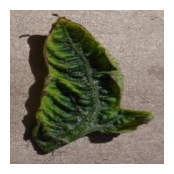

In [15]:
# Get image tensor
img_tensor = train_data[200][0]  # shape: (3,224,224)

# Denormalize 
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
img_denorm = img_tensor * std + mean

# Convert to numpy
img_np = img_denorm.permute(1,2,0).numpy()

# Plot
plt.figure(figsize=(2,2))
plt.imshow(img_np)
plt.axis('off')
plt.show()

**Explanation**

* Visual verification of the dataset and transformations

# Custom Model Architecture
*Try any one at once*

**Train With BN & Dropout**

In [16]:
# Get number of classes
num_classes = len(full_dataset.classes)

labels = np.array(full_dataset.targets)
class_counts = np.bincount(labels)
class_weights = 1. / (class_counts + 1e-6)      # inverse frequency
class_weights = class_weights / class_weights.sum() * num_classes  # normalize
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# CNN Model
class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()

        # Convolutional layers with BatchNorm
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),   # (3,224,224) -> (64,224,224)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (64,224,224) -> (64,112,112)
        
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # (64,112,112) -> (128,112,112)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (128,112,112) -> (128,56,56)
        
            nn.Conv2d(128, 256, kernel_size=3, padding=1),# (128,56,56) -> (256,56,56)
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (256,56,56) -> (256,28,28)
        
            nn.Conv2d(256, 256, kernel_size=3, padding=1),# (256,28,28) -> (256,28,28)
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (256,28,28) -> (256,14,14)
        
            nn.AdaptiveAvgPool2d((7,7))                   # (256,14,14) -> (256,7,7)
       )

        # Fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 7 * 7, 512),               
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Initialize model
model = CNNModel(num_classes=num_classes).to(device)

# Optimizer
optimizer = Adam(model.parameters(), lr=learning_rate)

# Scheduler
scheduler = CosineAnnealingLR(
    optimizer,
    T_max = epochs,
    eta_min = minimum_learning_rate
)

# Loss function with class weights to handle imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Model summary
from torchsummary import summary
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
       BatchNorm2d-2         [-1, 64, 224, 224]             128
              ReLU-3         [-1, 64, 224, 224]               0
         MaxPool2d-4         [-1, 64, 112, 112]               0
            Conv2d-5        [-1, 128, 112, 112]          73,856
       BatchNorm2d-6        [-1, 128, 112, 112]             256
              ReLU-7        [-1, 128, 112, 112]               0
         MaxPool2d-8          [-1, 128, 56, 56]               0
            Conv2d-9          [-1, 256, 56, 56]         295,168
      BatchNorm2d-10          [-1, 256, 56, 56]             512
             ReLU-11          [-1, 256, 56, 56]               0
        MaxPool2d-12          [-1, 256, 28, 28]               0
           Conv2d-13          [-1, 256, 28, 28]         590,080
      BatchNorm2d-14          [-1, 256,

**Explanation**

*BatchNorm improved learning stability*

* With BN: training becomes more stable
* Gradients are well-controlled: reduces exploding/vanishing issues
* Allows higher learning rates and faster convergence
* Result: better feature learning and higher accuracy

*Dropout reduced overfitting*
* With Dropout: neurons are randomly dea: learns more robust patterns
* Improves generalization on unseen data
* Result: higher validation/test accuracy

**Train Without BN & Dropout**

In [ ]:
# Get number of classes
num_classes = len(full_dataset.classes)

labels = np.array(full_dataset.targets)
class_counts = np.bincount(labels)
class_weights = 1. / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * num_classes
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# CNN Model (NO BatchNorm, NO Dropout)
class CNNModel_NoBN(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel_NoBN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),   # (3,224,224) -> (64,224,224)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (64,224,224) -> (64,112,112)

            nn.Conv2d(64, 128, kernel_size=3, padding=1), # (64,112,112) -> (128,112,112)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (128,112,112) -> (128,56,56)

            nn.Conv2d(128, 256, kernel_size=3, padding=1),# (128,56,56) -> (256,56,56)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (256,56,56) -> (256,28,28)

            nn.Conv2d(256, 256, kernel_size=3, padding=1),# (256,28,28) -> (256,28,28)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (256,28,28) -> (256,14,14)

            nn.AdaptiveAvgPool2d((7,7))                   # (256,14,14) -> (256,7,7)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Initialize model
model = CNNModel_NoBN(num_classes=num_classes).to(device)

# Optimizer
optimizer = Adam(model.parameters(), lr=learning_rate)

# Scheduler
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=epochs,
    eta_min=minimum_learning_rate
)

# Loss function
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Model summary
from torchsummary import summary
summary(model, input_size=(3, 224, 224))

**Explanation**

*BatchNorm helped learning stability*

* Without BN: training is less stable
* Gradients can explode/vanish: worse feature learning
* Result: lower accuracy


*Dropout reduced overfitting*

* Without Dropout: model memorizes training data
* Performs worse on unseen test data


# Training & Validation

In [17]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    # TRAINING
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = correct / total

    # Scheduler step
    scheduler.step()

    # Store results
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch [1/30] Train Loss: 1.5779, Train Acc: 0.4039 | Val Loss: 1.3473, Val Acc: 0.4143
Epoch [2/30] Train Loss: 0.8794, Train Acc: 0.5909 | Val Loss: 0.7471, Val Acc: 0.6322
Epoch [3/30] Train Loss: 0.6375, Train Acc: 0.6816 | Val Loss: 0.4998, Val Acc: 0.7306
Epoch [4/30] Train Loss: 0.5101, Train Acc: 0.7402 | Val Loss: 0.4296, Val Acc: 0.7820
Epoch [5/30] Train Loss: 0.4396, Train Acc: 0.7726 | Val Loss: 0.3194, Val Acc: 0.8312
Epoch [6/30] Train Loss: 0.3563, Train Acc: 0.8091 | Val Loss: 0.3206, Val Acc: 0.8361
Epoch [7/30] Train Loss: 0.3156, Train Acc: 0.8293 | Val Loss: 0.2510, Val Acc: 0.8639
Epoch [8/30] Train Loss: 0.2699, Train Acc: 0.8521 | Val Loss: 0.2112, Val Acc: 0.8968
Epoch [9/30] Train Loss: 0.2210, Train Acc: 0.8752 | Val Loss: 0.1943, Val Acc: 0.9021
Epoch [10/30] Train Loss: 0.2142, Train Acc: 0.8801 | Val Loss: 0.1647, Val Acc: 0.9334
Epoch [11/30] Train Loss: 0.1895, Train Acc: 0.8929 | Val Loss: 0.1483, Val Acc: 0.9356
Epoch [12/30] Train Loss: 0.1739, Train A

**Explanation**

1. *Training phase (model.train()):*
* Forward pass: compute predictions
* Compute loss with criterion
* Backpropagation: loss.backward(): update weights via optimizer.step()
* Track training loss and accuracy

2. *Validation phase (model.eval()):* 
* Forward pass only (no gradients)
* Compute validation loss and accuracy
3. *Scheduler step adjusts learning rate each epoch*
4. *Stores losses and accuracies for plotting later*
5. *Prints epoch-wise progress: training & validation loss and accuracy*

In [21]:
# Save the model weight
torch.save(model.state_dict(), "Custom_CNN_model_Leaf_Diseases.pth")

# Visualizations

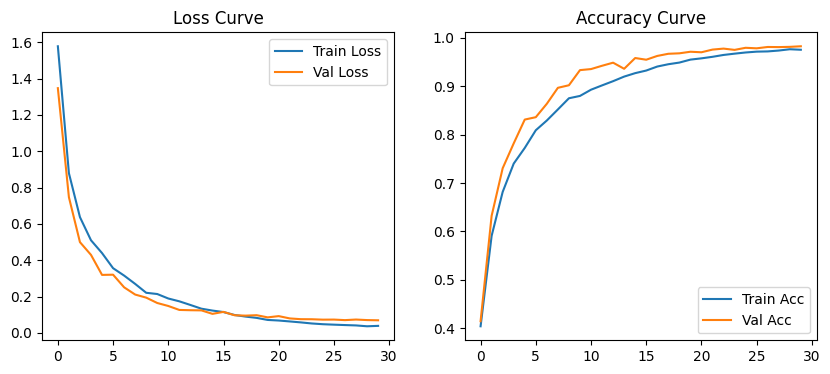

In [22]:
# Loss plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss Curve")

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.legend()
plt.title("Accuracy Curve")

plt.show()

**Explanation**

*This code visualizes model performance over training epochs.*

* The left plot (Loss Curve) shows how training and validation loss change over time. Helps check if the model is learning and whether it is overfitting or underfitting.

1. The right plot (Accuracy Curve) shows training and validation accuracy across epochs. Helps evaluate how well the model is improving and generalizing.

# Evaluate Model on Test Set

In [23]:
# Evaluation
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
# Accuracy finding
accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {accuracy:.4f}")

# Classification report
class_names = full_dataset.classes
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

Test Accuracy: 0.9803

Classification Report:

                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.98      0.98      0.98        96
                            Apple___Black_rot       0.99      0.95      0.97        97
                     Apple___Cedar_apple_rust       0.98      0.98      0.98        46
                              Apple___healthy       0.99      1.00      0.99       218
                    Background_without_leaves       0.98      0.99      0.99       173
                          Blueberry___healthy       0.99      1.00      0.99       232
                      Cherry___Powdery_mildew       0.98      1.00      0.99       157
                             Cherry___healthy       0.93      1.00      0.96       113
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.92      0.92      0.92        83
                           Corn___Common_rust       0.99      1.00      1.00      

**Explanation**

*This code evaluates the model on test data.*

* Sets model to evaluation mode and disables gradients
* Predicts labels for test images
* Calculates overall accuracy
* Prints a classification report (precision, recall, F1-score per class)

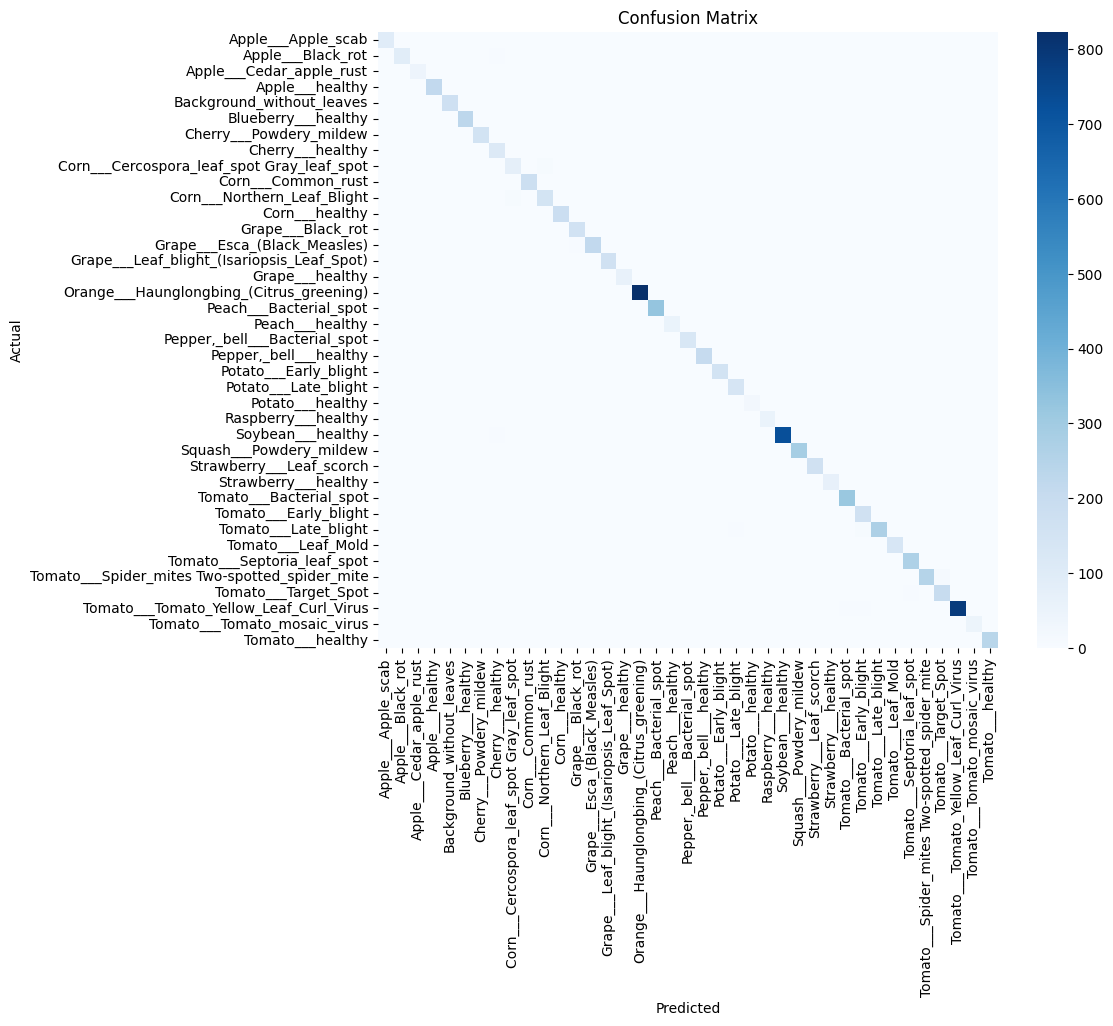

In [24]:
# Find confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Explanation**

*This code plots the confusion matrix to visualize model performance per class.*

* Computes the confusion matrix using true (all_labels) and predicted (all_preds) labels
* Uses a heatmap to show counts of correct and incorrect predictions for each class
* X-axis = predicted classes, Y-axis = actual classes
* Helps identify which classes the model confuses most

In [25]:
# Classification report(Best & Worst class)
report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)

f1_scores = {cls: report[cls]["f1-score"] for cls in class_names}

best_class = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)

print(f"\nBest performing class: {best_class} (F1: {f1_scores[best_class]:.4f})")
print(f"Worst performing class: {worst_class} (F1: {f1_scores[worst_class]:.4f})")


Best performing class: Corn___healthy (F1: 1.0000)
Worst performing class: Corn___Cercospora_leaf_spot Gray_leaf_spot (F1: 0.9157)


**Explanation**

*This code identifies the best and worst performing classes based on F1-score.*

* Converts the classification report into a dictionary (output_dict=True)
* Extracts F1-scores for all classes
* Finds the class with the highest F1-score: best performing
* Finds the class with the lowest F1-score: worst performing
* Prints the class names along with their F1-scores

# Analysis & Discussion of Results

The model trained on 55k images achieved strong performance with ~98% validation and test accuracy, showing good generalization and minimal overfitting. Training and validation metrics are very close, indicating stable learning. The confusion matrix is mostly diagonal, meaning most classes are correctly predicted with few errors. Best performance is seen in Corn___healthy (F1: 1.0), while slight confusion occurs in similar disease classes like Cercospora leaf spot (F1: 0.9157). The model is also efficient with 7.4M parameters.

# Conclusions & Future Work

The model is highly effective for plant disease classification with high accuracy and reliability. Future improvements can focus on handling similarlooking diseases, using stronger architectures, better data augmentation, and testing on real-world images. Deployment in mobile/web apps could make it practically useful.